## 2D Random Walk
With constant magnitude of displacement for each time step.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
displacement_mag = 1 #fixed the magnitude of discplacement to be constant
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

In [4]:
#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

In [5]:
def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1): 
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

In [6]:
#particle1 = generate_trajectory(1000, starting_position)
particle2 = generate_trajectory(10, starting_position)
particle3 = generate_trajectory(1000, starting_position)

#print(particle1)
print(particle2)

print(calculate_MSD(2, particle2))
#print(calculate_MSD(10, particle1))
print(calculate_MSD(50, particle3))

[array([ 0.        , -0.40907997, -0.91249853]), array([ 1.        , -0.49602774, -1.90871141]), array([ 2.        , -0.32506191, -2.89398836]), array([ 3.        ,  0.04111893, -1.96344466]), array([ 4.        ,  0.83722132, -2.5686066 ]), array([ 5.        ,  0.01286857, -3.13468304]), array([ 6.        , -0.96693406, -2.93471601]), array([ 7.00000000e+00,  1.35443972e-03, -2.68488131e+00]), array([ 8.        ,  0.56619003, -3.51008477]), array([ 9.        , -0.38822697, -3.80856123])]
2.865167005225061
44.346003600603915


[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


Text(0, 0.5, 'MSD (m)')

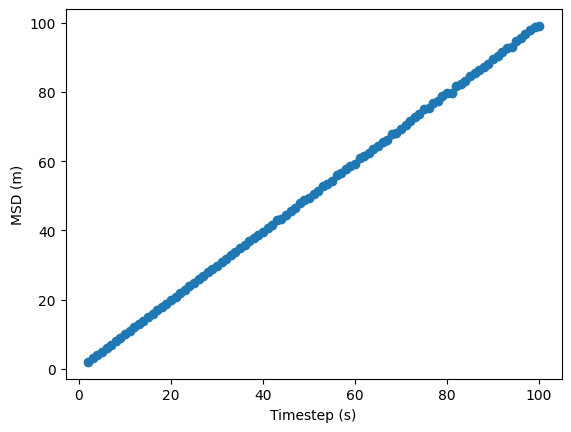

In [7]:
particle1 = generate_trajectory(1000000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

However, closer to actual Brownian motion, the magnitude of displacement need not be constant all the time… Instead it may be a more realistic simulation to choose a magnitude of displacement from a normal distribution for each time step. 

In [8]:
starting_position = np.array([0,0], dtype=float)

#generates a random direction
def generate_direction_vector():
    displacement_mag = np.random.normal(loc=1, scale=2)
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = displacement_mag*math.cos(angle)
    y_direction = displacement_mag*math.sin(angle)
    #print(displacement_mag)
    return [x_direction, y_direction]

#given a time duration and starting position, produces a random walk trajectory
def generate_trajectory(time, starting_position):
    trajectory = []
    current_position = starting_position.copy() 
    current_time = 0
    while current_time < time:
        current_position += generate_direction_vector().copy()
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
        current_time += 1
    return trajectory 

#calculate MSD 
def calculate_MSD(time_interval, trajectory):
    r2 = np.array([0,0], dtype=float)
    count = 0
    samples = trajectory[::time_interval]
    for i in range(1,len(samples)):
        r2 += ((samples[i] - samples[i-1])**2)[1:]
        count += 1
    msd = np.sum(r2)/(len(samples)-1)
    return msd

def generate_MSD_dataset(time, trajectory):
    time_data = [t for t in range(2,time+1)]
    msd_data = []
    for i in range(2, time+1):
        msd_data.append(calculate_MSD(i, trajectory))
    return [time_data, msd_data]

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


Text(0, 0.5, 'MSD (m)')

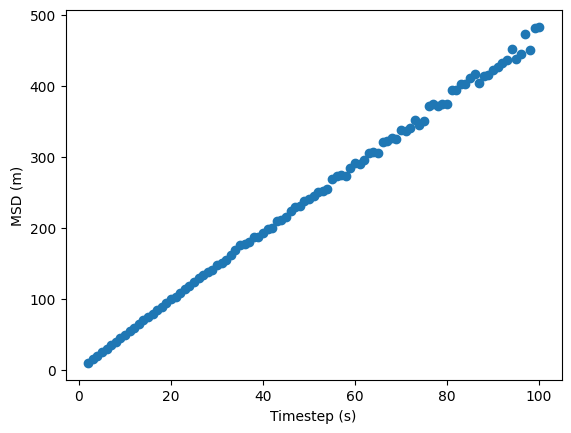

In [9]:
particle1 = generate_trajectory(100000, starting_position)
particle1_data = generate_MSD_dataset(100, particle1)

plt.scatter(particle1_data[0], particle1_data[1])
print(particle1_data[0])
plt.xlabel('Timestep (s)')
plt.ylabel('MSD (m)' )

What happens when we enforce boundaries on how far the particle can actually travel? Will that change the shape of the MSD on time graph? 

In [83]:
"""
(-5, 5) -------- (5,5)
|
|
|
|
(-5, -5) -------- (-5,5)

"""

def generate_direction_vector():
    angle = np.random.uniform(0, 2*math.pi) #in radians
    x_direction = math.cos(angle)
    y_direction = math.sin(angle)
    return np.array([x_direction, y_direction])

def rebound_at_boundary(boundary_x, boundary_y, next_step):
    #rightcorner
    magnitude = abs(next_step)
    boundary_violated = magnitude - np.array([boundary_x, boundary_y]) > np.array([0,0])
    x = next_step[0]
    y = next_step[1]
    if boundary_violated[0]:
        if x > 0:
            x = boundary_x - (x - boundary_x)
        else:
            x = -boundary_x - (x + boundary_x) 
    if boundary_violated[1]:
        if y > 0:
            y = boundary_y - (y - boundary_y)
        else:
            y = -boundary_y - (y + boundary_y)
    return np.array([x,y])
 
def generate_trajectory(time, starting_position, boundary_x, boundary_y):
    trajectory = [np.concatenate((np.array([0]), starting_position))]
    current_position = starting_position.copy()
    current_time = 0
    while current_time < time:
        current_time += 1
        next_step = current_position + generate_direction_vector().copy()
        current_position = rebound_at_boundary(boundary_x, boundary_y, next_step)
        trajectory.append(np.concatenate((np.array([current_time]), current_position)))
    return trajectory 

In [84]:
boundary_x = 1
boundary_y = 1
trajectory1 = generate_trajectory(10, np.array([0,0], dtype=float), boundary_x, boundary_y)
print(trajectory1)

[array([0., 0., 0.]), array([ 1.        , -0.6291604 , -0.77727549]), array([ 2.        ,  0.22958826, -0.26487845]), array([3.        , 0.77065466, 0.57610143]), array([4.        , 0.87069814, 0.4289155 ]), array([5.       , 0.0074117, 0.9336298]), array([ 6.        , -0.50610007,  0.07554725]), array([ 7.        , -0.04578805,  0.96330445]), array([8.        , 0.10258181, 0.04776361]), array([ 9.        , -0.87443872, -0.16538161]), array([10.        , -0.28375863, -0.70516702])]
